In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings 
warnings.filterwarnings("ignore")

In [5]:
df=pd.read_csv("TWO_CENTURIES_OF_UM_RACES.csv")

In [3]:
df.head(3)

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
0,2018,06.01.2018,Selva Costera (CHI),50km,22,4:51:39 h,Tnfrc,CHI,1978.0,M,M35,10.286,0
1,2018,06.01.2018,Selva Costera (CHI),50km,22,5:15:45 h,Roberto Echeverría,CHI,1981.0,M,M35,9.501,1
2,2018,06.01.2018,Selva Costera (CHI),50km,22,5:16:44 h,Puro Trail Osorno,CHI,1987.0,M,M23,9.472,2


In [6]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 7461195
Number of columns: 13


In [4]:
#information of datatypes:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7461195 entries, 0 to 7461194
Data columns (total 13 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   Year of event              int64  
 1   Event dates                object 
 2   Event name                 object 
 3   Event distance/length      object 
 4   Event number of finishers  int64  
 5   Athlete performance        object 
 6   Athlete club               object 
 7   Athlete country            object 
 8   Athlete year of birth      float64
 9   Athlete gender             object 
 10  Athlete age category       object 
 11  Athlete average speed      object 
 12  Athlete ID                 int64  
dtypes: float64(1), int64(3), object(9)
memory usage: 740.0+ MB


In [7]:
#Checking null values: 
df.isnull().sum()

Year of event                      0
Event dates                        0
Event name                         0
Event distance/length           1053
Event number of finishers          0
Athlete performance                2
Athlete club                 2826524
Athlete country                    3
Athlete year of birth         588161
Athlete gender                     7
Athlete age category          584938
Athlete average speed            224
Athlete ID                         0
dtype: int64

In [8]:
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 50


#### cleaning-up data (Only want USA Races,50k or 50 Mi,2020)####


In [9]:
df[df['Event distance/length']=='50mi'].head(3)

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
55,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge (USA),50mi,9,9:53:05 h,"*Middleville, MI",USA,1983.0,M,M23,8.141,55
56,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge (USA),50mi,9,11:09:35 h,"*Waterloo, ON",CAN,1977.0,F,W40,7.211,56
57,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge (USA),50mi,9,11:33:00 h,"*Kitchener, ON",CAN,1976.0,M,M40,6.967,57


#### Combine 50k/50mi ####

In [14]:
df[df['Event distance/length'].isin(['50km','50mi'])].head(3)

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
0,2018,06.01.2018,Selva Costera (CHI),50km,22,4:51:39 h,Tnfrc,CHI,1978.0,M,M35,10.286,0
1,2018,06.01.2018,Selva Costera (CHI),50km,22,5:15:45 h,Roberto Echeverría,CHI,1981.0,M,M35,9.501,1
2,2018,06.01.2018,Selva Costera (CHI),50km,22,5:16:44 h,Puro Trail Osorno,CHI,1987.0,M,M23,9.472,2


In [15]:
df[(df['Event distance/length'].isin(['50km','50mi']))&(df['Year of event']==2020)].head(3)

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
2538571,2020,07.-09.02.2020,Taipei 48hr Ultra Marathon - 50mi (TPE),50mi,38,7:34:19 h,日本隊,JPN,1965.0,M,M50,10.627,53107
2538572,2020,07.-09.02.2020,Taipei 48hr Ultra Marathon - 50mi (TPE),50mi,38,7:43:50 h,NaN,AUS,1974.0,M,M45,10.409,8785
2538573,2020,07.-09.02.2020,Taipei 48hr Ultra Marathon - 50mi (TPE),50mi,38,8:04:40 h,NaN,TPE,1976.0,M,M40,9.962,4502


In [16]:
# getting only usa data
df[df['Event name'].str.split('(').str.get(1).str.split(')').str.get(0)=='USA'].head(3)

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
55,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge (USA),50mi,9,9:53:05 h,"*Middleville, MI",USA,1983.0,M,M23,8.141,55
56,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge (USA),50mi,9,11:09:35 h,"*Waterloo, ON",CAN,1977.0,F,W40,7.211,56
57,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge (USA),50mi,9,11:33:00 h,"*Kitchener, ON",CAN,1976.0,M,M40,6.967,57


In [18]:
# year of 2020 data only and storing in different dataframe
df2=df[(df['Event distance/length'].isin(['50km', '50mi']))&(df['Year of event'] == 2020)&(df['Event name'].str.split('(').str.get(1).str.split(')').str.get(0) == 'USA')]

In [18]:
df2.head(3)

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
2539945,2020,02.02.2020,West Seattle Beach Run - Winter Edition (USA),50km,20,3:17:55 h,"*Normandy Park, WA",USA,1991.0,M,M23,15.158,71287
2539946,2020,02.02.2020,West Seattle Beach Run - Winter Edition (USA),50km,20,4:02:32 h,"*Gold Bar, WA",USA,1981.0,M,M35,12.369,629508
2539947,2020,02.02.2020,West Seattle Beach Run - Winter Edition (USA),50km,20,4:07:57 h,"*Vashon, WA",USA,1999.0,M,MU23,12.099,64838


In [19]:
df2.shape

(26090, 13)

In [20]:
#remove USA from event name
df2['Event name'] =  df2['Event name'].str.split('(').str.get(0)

In [26]:
df2['Event name'].head(3)

2539945    West Seattle Beach Run - Winter Edition 
2539946    West Seattle Beach Run - Winter Edition 
2539947    West Seattle Beach Run - Winter Edition 
Name: Event name, dtype: object

In [21]:
#Clean-up athelete age
df2['athlete age']=2020-df2['Athlete year of birth']
df2['athlete age'].head(3)

2539945    29.0
2539946    39.0
2539947    21.0
Name: athlete age, dtype: float64

In [9]:
#Remove h from athlete performance
df2['Athlete performance']=df2['Athlete performance'].str.split(' ').str.get(0)
df2['Athlete performance'].head(3)

2539945    3:17:55
2539946    4:02:32
2539947    4:07:57
Name: Athlete performance, dtype: object

In [22]:
#drop columns:Athlete Club,Athlete Country,Athlete year of birth,Athlete Age Category
df2=df2.drop(['Athlete club','Athlete country','Athlete year of birth','Athlete age category'],axis=1)

In [34]:
df2.head(3)

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete gender,Athlete average speed,Athlete ID,athlete age
2539945,2020,02.02.2020,West Seattle Beach Run - Winter Edition,50km,20,3:17:55,M,15.158,71287,29.0
2539946,2020,02.02.2020,West Seattle Beach Run - Winter Edition,50km,20,4:02:32,M,12.369,629508,39.0
2539947,2020,02.02.2020,West Seattle Beach Run - Winter Edition,50km,20,4:07:57,M,12.099,64838,21.0


In [23]:
#clean-up null values 
df2.isnull().sum()

Year of event                  0
Event dates                    0
Event name                     0
Event distance/length          0
Event number of finishers      0
Athlete performance            0
Athlete gender                 0
Athlete average speed          0
Athlete ID                     0
athlete age                  233
dtype: int64

In [24]:
df2[df2['athlete age'].isna()==1].head(3)

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete gender,Athlete average speed,Athlete ID,athlete age
2547794,2020,25.01.2020,North Carolina Fat Ass 50 Km,50km,57,6:10:30 h,M,8.097,811923,NaN
2551331,2020,19.01.2020,Big Bend 50 - Fresno Creek 50K,50km,54,4:46:34 h,M,10.469,812656,NaN
2551336,2020,19.01.2020,Big Bend 50 - Fresno Creek 50K,50km,54,5:08:36 h,M,9.721,812657,NaN


In [25]:
df2=df2.dropna()

In [26]:
df2.shape

(25857, 10)

In [27]:
#Check for duplicates
df2.duplicated().sum()


np.int64(0)

In [28]:
#reset index
df2.reset_index(drop=True).head(3)

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete gender,Athlete average speed,Athlete ID,athlete age
0,2020,02.02.2020,West Seattle Beach Run - Winter Edition,50km,20,3:17:55 h,M,15.158,71287,29.0
1,2020,02.02.2020,West Seattle Beach Run - Winter Edition,50km,20,4:02:32 h,M,12.369,629508,39.0
2,2020,02.02.2020,West Seattle Beach Run - Winter Edition,50km,20,4:07:57 h,M,12.099,64838,21.0


In [29]:
#fix Types
df2.dtypes

Year of event                  int64
Event dates                   object
Event name                    object
Event distance/length         object
Event number of finishers      int64
Athlete performance           object
Athlete gender                object
Athlete average speed         object
Athlete ID                     int64
athlete age                  float64
dtype: object

In [30]:
df2['athlete age']=df2['athlete age'].astype(int)
df2['Athlete average speed']=df2['Athlete average speed'].astype(float)

In [31]:
df2.dtypes

Year of event                  int64
Event dates                   object
Event name                    object
Event distance/length         object
Event number of finishers      int64
Athlete performance           object
Athlete gender                object
Athlete average speed        float64
Athlete ID                     int64
athlete age                    int64
dtype: object

In [46]:
df2.head(3)

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete gender,Athlete average speed,Athlete ID,athlete age
2539945,2020,02.02.2020,West Seattle Beach Run - Winter Edition,50km,20,3:17:55,M,15.158,71287,29
2539946,2020,02.02.2020,West Seattle Beach Run - Winter Edition,50km,20,4:02:32,M,12.369,629508,39
2539947,2020,02.02.2020,West Seattle Beach Run - Winter Edition,50km,20,4:07:57,M,12.099,64838,21


In [32]:
#rename columns
df2=df2.rename(columns={'Year of event':'year','Event dates':'race_day',
                        'Event name':'race_name','Event distance/length':'race_length',
                        'Event number of finishers':'race_number_of_finishers',
                        'Athlete performance':'athlete_performance','Athlete gender':'athlete_gender',
                        'Athlete average speed':'athlete_average_speed','Athlete ID':'athlete_id','athlete age':'athlete_age'})

In [48]:
df2.columns

Index(['year', 'race_day', 'race_name', 'race_length',
       'race_number_of_finishers', 'athlete_performance', 'athlete_gender',
       'athlete_average_speed', 'athlete_id', 'athlete_age'],
      dtype='object')

In [33]:
#reorder columns
df3=df2[['race_day','race_name','race_length','race_number_of_finishers',
         'athlete_id','athlete_gender','athlete_age','athlete_performance','athlete_average_speed','year']]

In [34]:
df3.columns

Index(['race_day', 'race_name', 'race_length', 'race_number_of_finishers',
       'athlete_id', 'athlete_gender', 'athlete_age', 'athlete_performance',
       'athlete_average_speed', 'year'],
      dtype='object')

In [71]:
df2.shape

(25857, 10)

In [50]:
df3.head(3)

,race_day,race_name,race_length,race_number_of_finishers,athlete_id,athlete_gender,athlete_age,athlete_performance,athlete_average_speed,year
2539945,02.02.2020,West Seattle Beach Run - Winter Edition,50km,20,71287,M,29,3:17:55,15.158,2020
2539946,02.02.2020,West Seattle Beach Run - Winter Edition,50km,20,629508,M,39,4:02:32,12.369,2020
2539947,02.02.2020,West Seattle Beach Run - Winter Edition,50km,20,64838,M,21,4:07:57,12.099,2020


#### some questions

In [51]:
#find 2 races that ran in 2020 -sarosta/everglades
df3[df3['race_name']=='Everglades 50 Mile Ultra Run '].head(2)

,race_day,race_name,race_length,race_number_of_finishers,athlete_id,athlete_gender,athlete_age,athlete_performance,athlete_average_speed,year
2591476,14.03.2020,Everglades 50 Mile Ultra Run,50mi,40,820757,M,27,8:31:39,9.436,2020
2591477,14.03.2020,Everglades 50 Mile Ultra Run,50mi,40,46432,M,39,8:31:48,9.433,2020


In [52]:
df3[df3['athlete_id']==222509]

,race_day,race_name,race_length,race_number_of_finishers,athlete_id,athlete_gender,athlete_age,athlete_performance,athlete_average_speed,year
2591482,14.03.2020,Everglades 50 Mile Ultra Run,50mi,40,222509,M,23,9:19:10,8.634,2020
2616900,22.02.2020,Manasota Track Club 50K,50km,36,222509,M,23,4:49:16,10.371,2020


In [57]:
#Difference in speed for the 50k,50mi male to female
df3.groupby(['race_length','athlete_gender'])['athlete_average_speed'].mean()

race_length  athlete_gender
50km         F                 7.083011
             M                 7.738985
50mi         F                 6.834371
             M                 7.257633
Name: athlete_average_speed, dtype: float64

#### Which race distance is more popular? ####

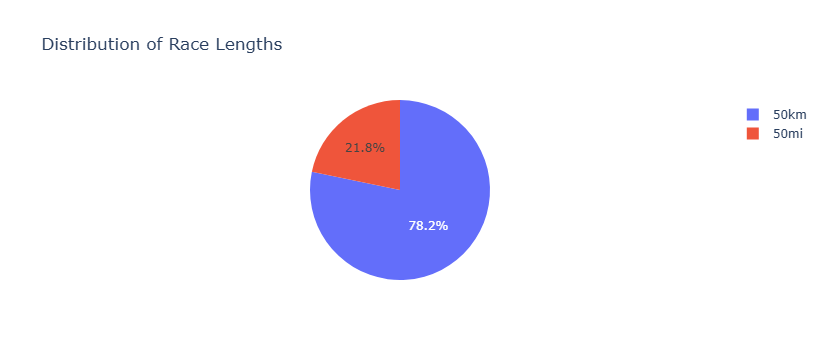

In [75]:
race_length_count = df3['race_length'].value_counts()
fig = px.pie(
    values=race_length_count.values,
    names=race_length_count.index,
    title='Distribution of Race Lengths'
)
fig.show()

#### What is the gender distribution among athletes?

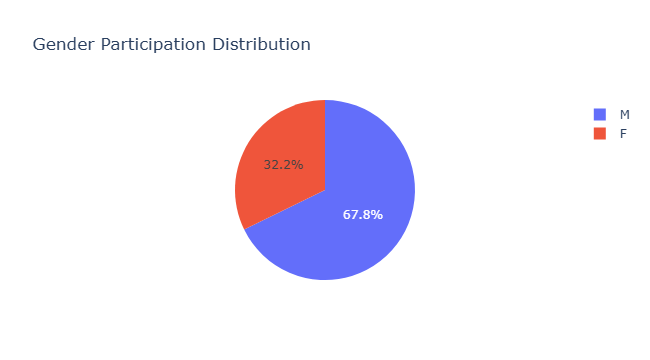

In [76]:
gender_count = df3['athlete_gender'].value_counts()
fig = px.pie(
    values=gender_count.values,
    names=gender_count.index,
    title='Gender Participation Distribution'
)
fig.show()

#### Male vs Female Speed Comparison

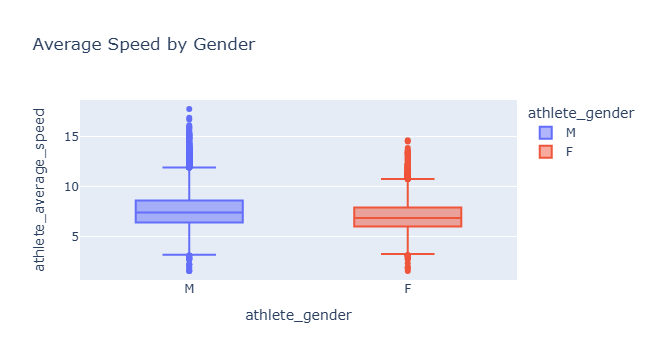

In [77]:
fig = px.box(
    df3,
    x='athlete_gender',
    y='athlete_average_speed',
    color='athlete_gender',
    title='Average Speed by Gender'
)
fig.show()

#### 50km vs 50mi Speed Comparison 
#### does distance affect speed of runners?

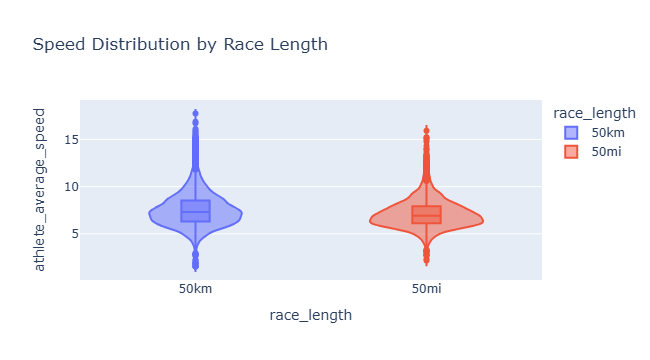

In [82]:
fig = px.violin(
    df3,
    x='race_length',
    y='athlete_average_speed',
    color='race_length',
    box=True,
    title='Speed Distribution by Race Length'
)

fig.show()

#### Top 10 Fastest Events

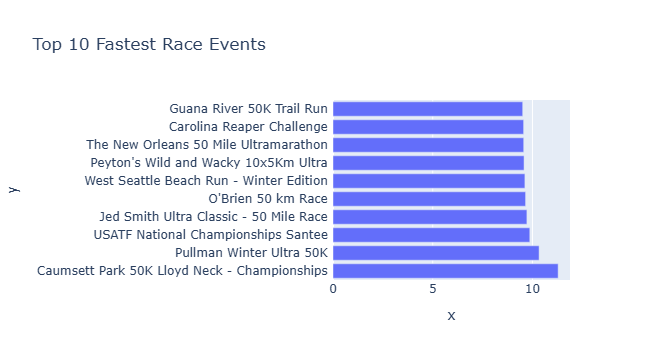

In [84]:
top_events = (df3.groupby('race_name')['athlete_average_speed'].mean().sort_values(ascending=False).head(10))
fig = px.bar(
    x=top_events.values,
    y=top_events.index,
    orientation='h',
    title='Top 10 Fastest Race Events'
)
fig.show()

#### Age vs Speed Relationship

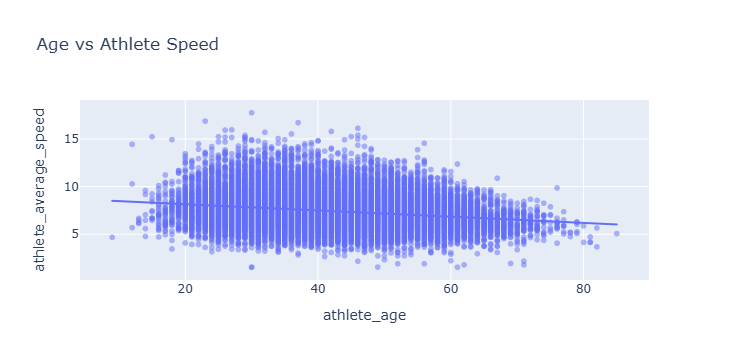

In [85]:
fig = px.scatter(
    df3,
    x='athlete_age',
    y='athlete_average_speed',
    trendline='ols',
    opacity=0.5,
    title='Age vs Athlete Speed'
)
fig.show()

#### Best Performing Age Group

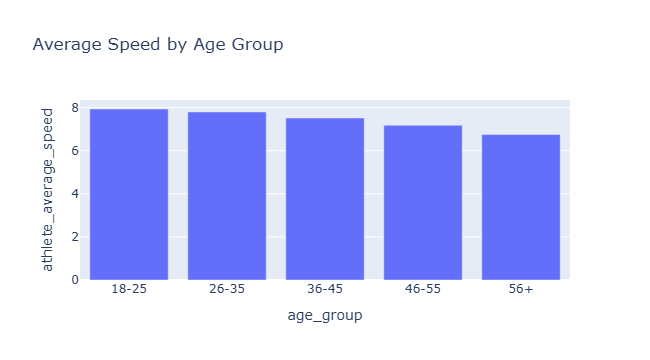

In [86]:
bins = [18,25,35,45,55,100]
labels = ['18-25','26-35','36-45','46-55','56+']
df3['age_group'] = pd.cut(df3['athlete_age'],bins=bins,labels=labels)
speed_age = (df3.groupby('age_group')['athlete_average_speed'].mean().reset_index())

fig = px.bar(
    speed_age,
    x='age_group',
    y='athlete_average_speed',
    title='Average Speed by Age Group'
)
fig.show()

#### Which age group participates the most?

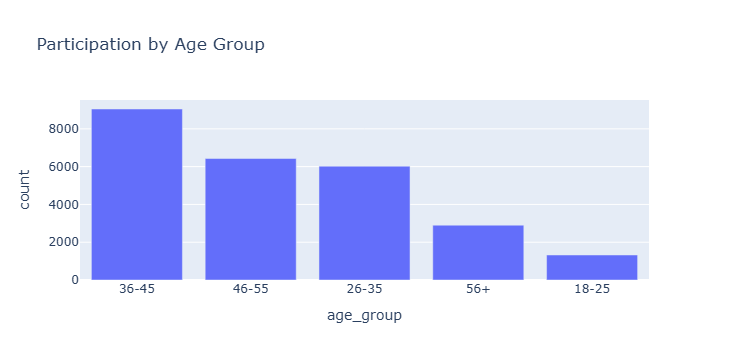

In [87]:
age_count = (df3['age_group'].value_counts().reset_index())
age_count.columns = ['age_group','count']
fig = px.bar(
    age_count,
    x='age_group',
    y='count',
    title='Participation by Age Group'
)
fig.show()

#### Which season hosts the most races?

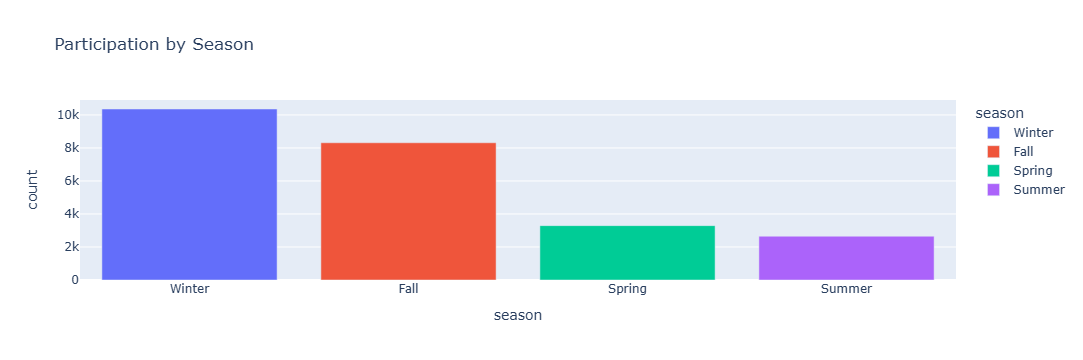

In [37]:
df3['race_month'] = df3['race_day'].str.split('.').str[1].astype(int)
season_mapping = {
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Fall', 10: 'Fall', 11: 'Fall'
}
df3['race_season'] = df3['race_month'].map(season_mapping)

season_count = (df3['race_season'].value_counts().reset_index())
season_count.columns = ['season','count']
fig = px.bar(
    season_count,
    x='season',
    y='count',
    color='season',
    title='Participation by Season'
)

fig.show()

#### Does season affect performance? ( avg speed using )

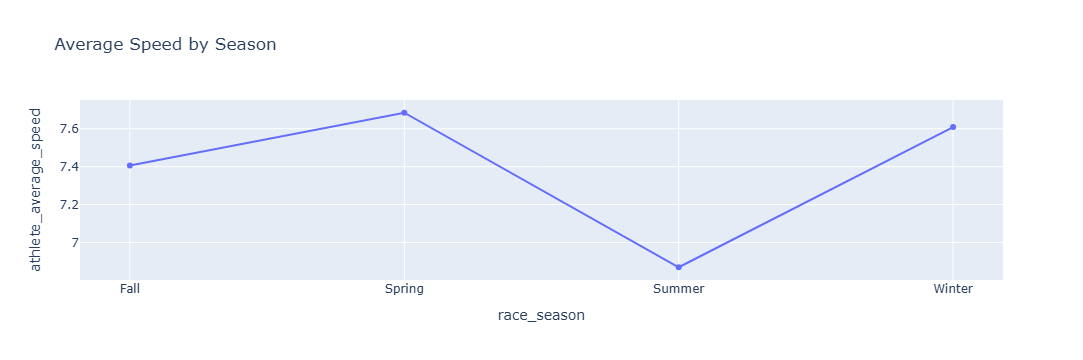

In [38]:
season_speed = (df3.groupby('race_season')['athlete_average_speed'].mean().reset_index())
fig = px.line(
    season_speed,
    x='race_season',
    y='athlete_average_speed',
    markers=True,
    title='Average Speed by Season'
)
fig.show()

#### Which age groups dominate each race distance?(heatmap)

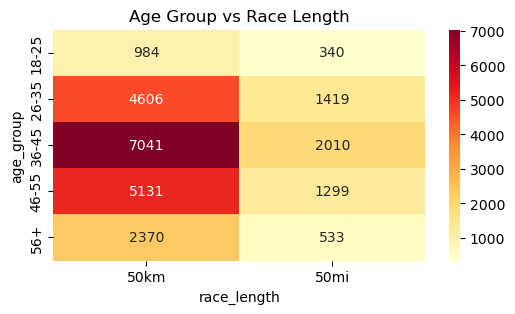

In [92]:
heat = pd.crosstab(df3['age_group'],df3['race_length'])
plt.figure(figsize=(6,3))
sns.heatmap(heat,annot=True,cmap='YlOrRd',fmt='d')
plt.title('Age Group vs Race Length')
plt.show()

#### Which races attract the most runners? (Top 15 Events by Participation)

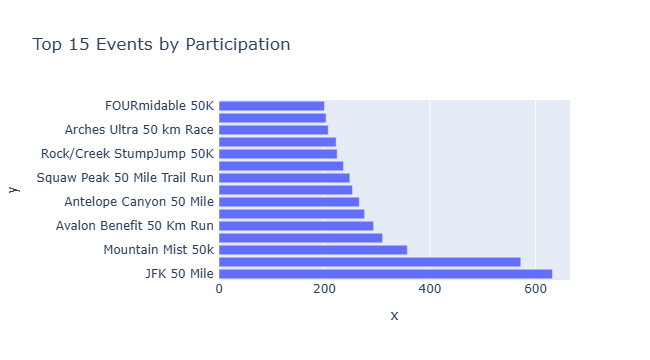

In [94]:
top_events = (df3.groupby('race_name')['athlete_id'].count().sort_values(ascending=False).head(15))
fig = px.bar(
    x=top_events.values,
    y=top_events.index,
    orientation='h',
    title='Top 15 Events by Participation'
)
fig.show()

#### Do larger events produce faster performances?

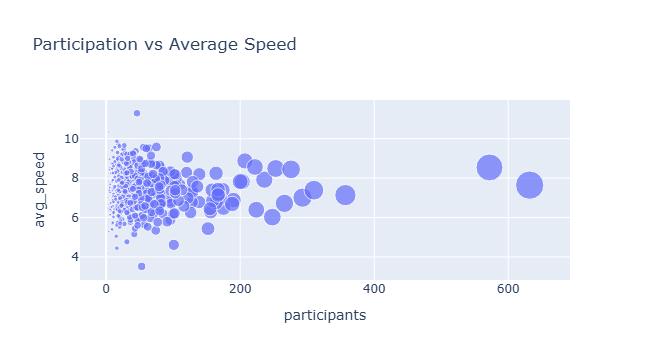

In [95]:
event_stats = ( df3.groupby('race_name')
        .agg(participants=('athlete_id','count'),avg_speed=('athlete_average_speed','mean')).reset_index())
fig = px.scatter(
    event_stats,
    x='participants',
    y='avg_speed',
    size='participants',
    hover_name='race_name',
    title='Participation vs Average Speed'
)
fig.show()

#### Do Larger Races Attract Slower Runners?
(Is there a relationship between event size and average performance?)

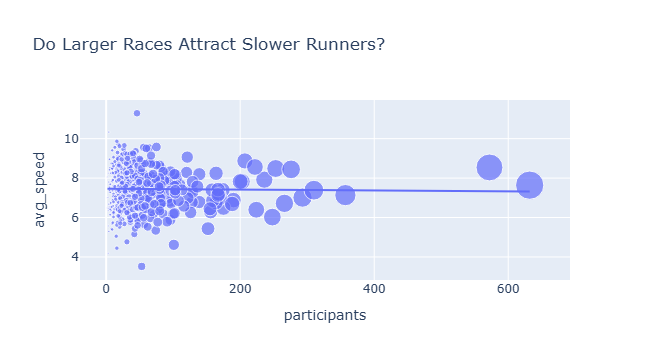

In [96]:
event_stats = (df3.groupby('race_name')
    .agg(participants=('athlete_id','count'),avg_speed=('athlete_average_speed','mean')).reset_index())

fig = px.scatter(
    event_stats,
    x='participants',
    y='avg_speed',
    size='participants',
    hover_name='race_name',
    trendline='ols',
    title='Do Larger Races Attract Slower Runners?'
)
fig.show()

#### Are Older Athletes Overrepresented In Longer Races?
Do older runners prefer 50mi races over 50km races?

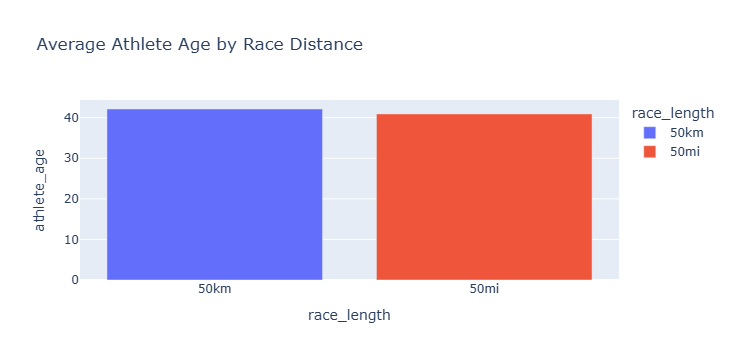

In [97]:
distance_age = (df3.groupby('race_length')['athlete_age'].mean().reset_index())
fig = px.bar(
    distance_age,
    x='race_length',
    y='athlete_age',
    color='race_length',
    title='Average Athlete Age by Race Distance'
)

fig.show()

#### Which Races Appear To Be The Most Difficult?
Which races have the lowest average speeds? or
Lower average speed often suggests tougher courses.

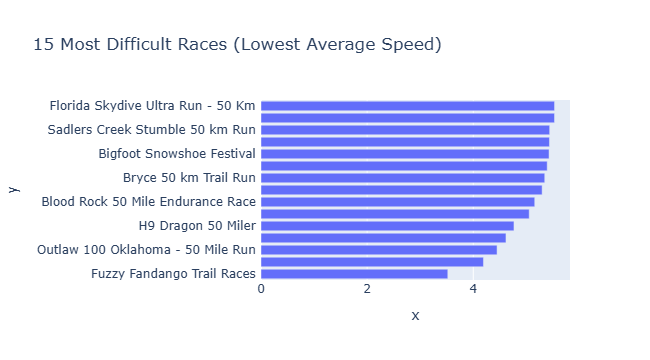

In [98]:
hardest_races = (df3.groupby('race_name')['athlete_average_speed'].mean().sort_values().head(15))
fig = px.bar(
    x=hardest_races.values,
    y=hardest_races.index,
    orientation='h',
    title='15 Most Difficult Races (Lowest Average Speed)'
)
fig.show()

#### Which Season Produces The Fastest Runners?

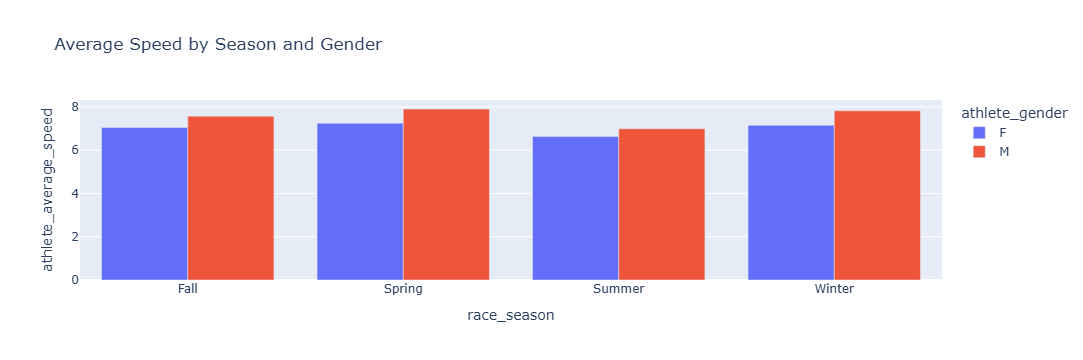

In [39]:
season_gender = (df3.groupby(['race_season','athlete_gender'])['athlete_average_speed'].mean().reset_index())
fig = px.bar(
    season_gender,
    x='race_season',
    y='athlete_average_speed',
    color='athlete_gender',
    barmode='group',
    title='Average Speed by Season and Gender'
)
fig.show()

#### Which Race Is The Most Competitive?
Logic
A race is considered more competitive if runners finish with similar speeds.

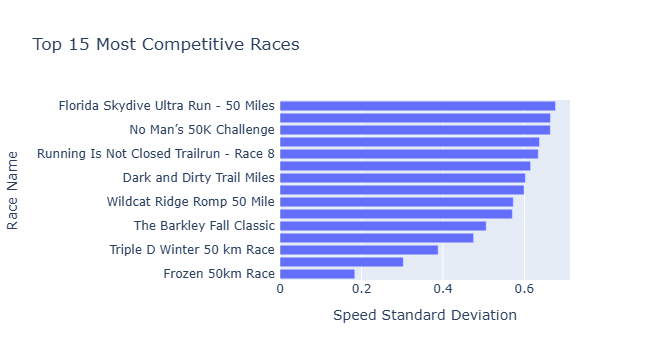

In [101]:
competitive_races = (df3.groupby('race_name')['athlete_average_speed'].std().sort_values().head(15))
fig = px.bar(
    x=competitive_races.values,
    y=competitive_races.index,
    orientation='h',
    title='Top 15 Most Competitive Races',
    labels={
        'x':'Speed Standard Deviation',
        'y':'Race Name'
    }
)
fig.show()